In [87]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# **1.1 Generating a black-and-white sketch**

In [88]:
gray_img = cv2.imread('Eden10.webp', 0)
print(gray_img.shape)
print(type(gray_img))

(612, 408)
<class 'numpy.ndarray'>


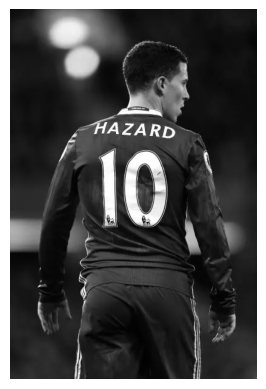

In [89]:
plt.imshow(gray_img, cmap='gray')
plt.axis('off')
plt.show()

In [90]:
unique_values = np.unique(gray_img)
print(unique_values)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

## 1.1.1 Noise Reduction Using Median Filter

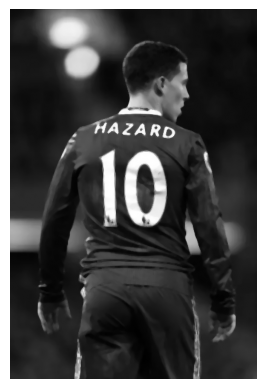

In [91]:
blured = cv2.medianBlur(gray_img, ksize=5)
plt.imshow(blured, cmap='gray')
plt.axis('off')
plt.show()

In [92]:
unique_values = np.unique(blured)
print(unique_values)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246 24

## 1.1.2 Edge Detection Using Laplacian Filter


float64
uint8


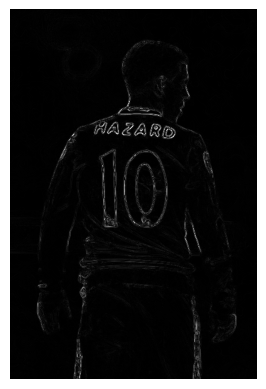

In [93]:
laplacian = cv2.Laplacian(blured, cv2.CV_64F) 
# The Laplacian operation involves subtraction, so results can be negative (edges can go from dark→light or light→dark).
# Using CV_64F (a 64-bit float) ensures those negative values are not clipped or lost.

print(laplacian.dtype)  # -> float64 (contains negatives)

laplacian = cv2.convertScaleAbs(laplacian)
print(laplacian.dtype)  # -> uint8 (0–255, displayable)

plt.imshow(laplacian, cmap='gray')
plt.axis('off')
plt.show()

## 1.1.3 Edges Thresholding

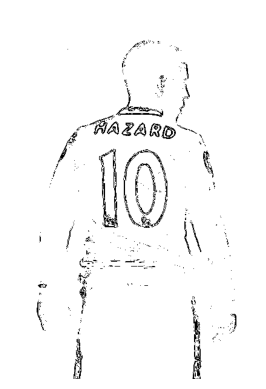

In [94]:
thresholding_laplacian = np.zeros((1, 612, 408))
_, thresholding_laplacian = cv2.threshold(laplacian, 30, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresholding_laplacian, cmap='gray')
plt.axis('off')
plt.show()

In [95]:
unique_values = np.unique(thresholding_laplacian)
print(unique_values)

[  0 255]


# **1.2 Generating a color painting and a cartoon**


In [96]:
color_img = cv2.imread('Eden10.webp')
color_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB) 


## 1.2.1 Applying Bilateral Filter

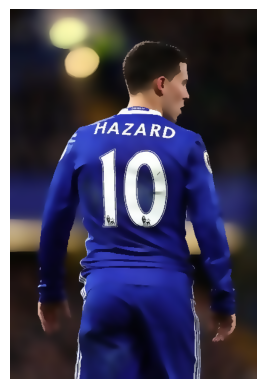

In [97]:
d = 9         # filter size 
sigmaR = 50   # Only pixels with very similar colors are averaged → edges are kept sharp
sigmaS = 255 

painting = color_img
for _ in range(5):  
    painting = cv2.bilateralFilter(painting, d, sigmaR, sigmaS)
    
plt.imshow(painting)
plt.axis('off')
plt.show()

## 1.2.2 Creating Cartoon Effect


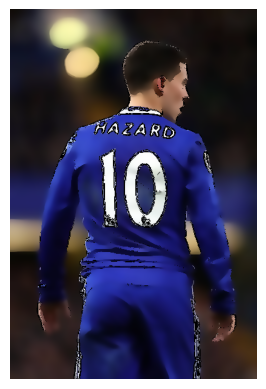

In [98]:
final_output = cv2.bitwise_and(painting, painting, mask=thresholding_laplacian)
# Where the mask is white (255, "not an edge"), it will keep the pixel from the painting.
# Where the mask is black (0, "is an edge"), it will replace the pixel with black.

plt.imshow(final_output)
plt.axis('off')
plt.show()